# Machine Learning Lab - Assignment 2
**MIS: 112415075**

I kept every asked part in a separate code cell.

## Imports

In [1]:
# importing stuff
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Q1

For the given matrix:
- find row-wise mean
- make binary matrix using row mean
- count 1s in every row
- find row(s) having maximum count

In [2]:
# given matrix
A = np.array([
    [12, 5, 8, 20],
    [7, 15, 3, 11],
    [25, 9, 18, 6],
    [10, 14, 2, 16]
])

print(A)

[[12  5  8 20]
 [ 7 15  3 11]
 [25  9 18  6]
 [10 14  2 16]]


In [3]:
# finding mean of each row
mean = A.mean(axis=1)

print(mean)

[11.25  9.   14.5  10.5 ]


In [4]:
# making binary matrix
binary = (A > mean[:, None]).astype(int)

print(binary)

[[1 0 0 1]
 [0 1 0 1]
 [1 0 1 0]
 [0 1 0 1]]


In [5]:
# counting 1 in each row
count = binary.sum(axis=1)

print(count)

[2 2 2 2]


In [6]:
# finding max count
max_count = count.max()

print(max_count)

2


In [7]:
# rows having max count
rows = np.where(count == max_count)[0] + 1

print("row(s):", rows)

row(s): [1 2 3 4]


## Q2

For each column:
- find mean and standard deviation
- find outliers using `|x - mean| > 2 * std`
- find column median
- replace outlier by its column median

In [8]:
# given data
X = np.array([
    [10, 100, 5],
    [12, 110, 6],
    [11, 105, 7],
    [13, 500, 6],
    [14, 108, 8],
    [15, 115, 9]
], dtype=float)

print(X)

[[ 10. 100.   5.]
 [ 12. 110.   6.]
 [ 11. 105.   7.]
 [ 13. 500.   6.]
 [ 14. 108.   8.]
 [ 15. 115.   9.]]


In [9]:
# column mean
mean = X.mean(axis=0)

print(mean)

[ 12.5        173.           6.83333333]


In [10]:
# column standard deviation
std = X.std(axis=0)

print(std)

[  1.70782513 146.31017281   1.34370962]


In [11]:
# checking outliers
outlier = np.abs(X - mean) > 2 * std

print(outlier)

[[False False False]
 [False False False]
 [False False False]
 [False  True False]
 [False False False]
 [False False False]]


In [12]:
# column median
median = np.median(X, axis=0)

print(median)

[ 12.5 109.    6.5]


In [13]:
# replacing outlier with median
clean_X = np.where(outlier, median, X)

print(clean_X)

[[ 10. 100.   5.]
 [ 12. 110.   6.]
 [ 11. 105.   7.]
 [ 13. 109.   6.]
 [ 14. 108.   8.]
 [ 15. 115.   9.]]


## Q3

Using the given student DataFrame:
1. average marks department-wise
2. average marks by department and gender
3. highest-mark student in each department
4. students above their department average
5. average attendance and department having highest average attendance

In [14]:
# making dataframe
df = pd.DataFrame({
    "Student": ["A", "B", "C", "D", "E", "F", "G", "H"],
    "Department": ["CSE", "CSE", "ECE", "ECE", "CSE", "ECE", "CSE", "ECE"],
    "Gender": ["F", "M", "F", "M", "M", "F", "F", "M"],
    "Marks": [85, 72, 91, 65, 78, 88, 95, 70],
    "Attendance": [92, 81, 96, 72, 85, 90, 98, 75]
})

print(df)

  Student Department Gender  Marks  Attendance
0       A        CSE      F     85          92
1       B        CSE      M     72          81
2       C        ECE      F     91          96
3       D        ECE      M     65          72
4       E        CSE      M     78          85
5       F        ECE      F     88          90
6       G        CSE      F     95          98
7       H        ECE      M     70          75


In [15]:
# 1 average marks department wise
ans1 = df.groupby("Department")["Marks"].mean()

print(ans1)

Department
CSE    82.5
ECE    78.5
Name: Marks, dtype: float64


In [16]:
# 2 average marks by department and gender
ans2 = df.groupby(["Department", "Gender"])["Marks"].mean()

print(ans2)

Department  Gender
CSE         F         90.0
            M         75.0
ECE         F         89.5
            M         67.5
Name: Marks, dtype: float64


In [17]:
# 3 highest marks student in each department
index = df.groupby("Department")["Marks"].idxmax()
ans3 = df.loc[index, ["Department", "Student", "Marks"]]

print(ans3.to_string(index=False))

Department Student  Marks
       CSE       G     95
       ECE       C     91


In [18]:
# 4 getting department average for every student
dept_avg = df.groupby("Department")["Marks"].transform("mean")

print(dept_avg)

0    82.5
1    82.5
2    78.5
3    78.5
4    82.5
5    78.5
6    82.5
7    78.5
Name: Marks, dtype: float64


In [19]:
# students above their department average
ans4 = df[df["Marks"] > dept_avg]

print(ans4[["Student", "Department", "Marks"]].to_string(index=False))

Student Department  Marks
      A        CSE     85
      C        ECE     91
      F        ECE     88
      G        CSE     95


In [20]:
# 5 average attendance department wise
attendance = df.groupby("Department")["Attendance"].mean()

print(attendance)

Department
CSE    89.00
ECE    83.25
Name: Attendance, dtype: float64


In [21]:
# department with highest attendance
print(attendance.idxmax())

CSE


## Q4

For the given records:
1. identify duplicated IDs
2. check if repeated records are identical
3. keep highest score for repeated ID
4. make clean DataFrame
5. find number of removed records

In [22]:
# given records
df = pd.DataFrame({
    "ID": [101, 102, 103, 101, 104, 102, 105],
    "Name": ["A", "B", "C", "A", "D", "B", "E"],
    "Age": [20, 21, 22, 20, 23, 21, 24],
    "Score": [80, 75, 90, 85, 88, 75, 92]
})

print(df)

    ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
2  103    C   22     90
3  101    A   20     85
4  104    D   23     88
5  102    B   21     75
6  105    E   24     92


In [23]:
# 1 finding repeated ids
dup_ids = df.loc[df["ID"].duplicated(keep=False), "ID"].unique()

print(dup_ids)

[101 102]


In [24]:
# 2 taking only repeated records
dup_rows = df[df["ID"].isin(dup_ids)]

print(dup_rows)

    ID Name  Age  Score
0  101    A   20     80
1  102    B   21     75
3  101    A   20     85
5  102    B   21     75


In [25]:
# checking if repeated rows are same
same = dup_rows.groupby("ID").nunique(dropna=False).le(1).all(axis=1)

print(same)

ID
101    False
102     True
dtype: bool


In [26]:
# 3 keeping highest score for each id
best_index = df.groupby("ID")["Score"].idxmax()

print(best_index)

ID
101    3
102    1
103    2
104    4
105    6
Name: Score, dtype: int64


In [27]:
# 4 clean dataframe
clean_df = df.loc[best_index].sort_values("ID").reset_index(drop=True)

print(clean_df)

    ID Name  Age  Score
0  101    A   20     85
1  102    B   21     75
2  103    C   22     90
3  104    D   23     88
4  105    E   24     92


In [28]:
# 5 records removed
removed = len(df) - len(clean_df)

print(removed)

2


## Q5

For the sales data:
1. find missing dates
2. add the missing dates and find 3-day rolling average
3. find date with maximum rolling average

In [29]:
# sales data
df = pd.DataFrame({
    "Date": [
        "2026-01-01", "2026-01-02", "2026-01-04",
        "2026-01-05", "2026-01-08", "2026-01-09"
    ],
    "Sales": [100, 120, 150, 130, 180, 200]
})

print(df)

         Date  Sales
0  2026-01-01    100
1  2026-01-02    120
2  2026-01-04    150
3  2026-01-05    130
4  2026-01-08    180
5  2026-01-09    200


In [30]:
# changing date to datetime
df["Date"] = pd.to_datetime(df["Date"])
df = df.set_index("Date")

print(df)

            Sales
Date             
2026-01-01    100
2026-01-02    120
2026-01-04    150
2026-01-05    130
2026-01-08    180
2026-01-09    200


In [31]:
# 1 making full date range
all_dates = pd.date_range(df.index.min(), df.index.max(), freq="D")

print(all_dates)

DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08',
               '2026-01-09'],
              dtype='datetime64[ns]', freq='D')


In [32]:
# finding missing dates
missing = all_dates.difference(df.index)

print(missing)

DatetimeIndex(['2026-01-03', '2026-01-06', '2026-01-07'], dtype='datetime64[ns]', freq=None)


In [33]:
# 2 adding missing dates
df = df.reindex(all_dates)
df.index.name = "Date"

print(df)

            Sales
Date             
2026-01-01  100.0
2026-01-02  120.0
2026-01-03    NaN
2026-01-04  150.0
2026-01-05  130.0
2026-01-06    NaN
2026-01-07    NaN
2026-01-08  180.0
2026-01-09  200.0


In [34]:
# finding 3 day rolling average
df["Rolling_Avg"] = df["Sales"].rolling(3, min_periods=1).mean()

print(df)

            Sales  Rolling_Avg
Date                          
2026-01-01  100.0        100.0
2026-01-02  120.0        110.0
2026-01-03    NaN        110.0
2026-01-04  150.0        135.0
2026-01-05  130.0        140.0
2026-01-06    NaN        140.0
2026-01-07    NaN        130.0
2026-01-08  180.0        180.0
2026-01-09  200.0        190.0


In [35]:
# 3 finding max rolling average date
max_date = df["Rolling_Avg"].idxmax()

print(max_date)
print(df.loc[max_date, "Rolling_Avg"])

2026-01-09 00:00:00
190.0


## Q6

Without using loops:
1. find 5 x 5 pairwise Euclidean distance matrix
2. find pair of points having maximum distance
3. print maximum distance

In [36]:
# given points
points = np.array([
    [1, 2],
    [4, 6],
    [7, 3],
    [2, 8],
    [9, 5]
], dtype=float)

print(points)

[[1. 2.]
 [4. 6.]
 [7. 3.]
 [2. 8.]
 [9. 5.]]


In [37]:
# 1 getting difference using broadcasting
diff = points[:, None, :] - points[None, :, :]

print(diff)

[[[ 0.  0.]
  [-3. -4.]
  [-6. -1.]
  [-1. -6.]
  [-8. -3.]]

 [[ 3.  4.]
  [ 0.  0.]
  [-3.  3.]
  [ 2. -2.]
  [-5.  1.]]

 [[ 6.  1.]
  [ 3. -3.]
  [ 0.  0.]
  [ 5. -5.]
  [-2. -2.]]

 [[ 1.  6.]
  [-2.  2.]
  [-5.  5.]
  [ 0.  0.]
  [-7.  3.]]

 [[ 8.  3.]
  [ 5. -1.]
  [ 2.  2.]
  [ 7. -3.]
  [ 0.  0.]]]


In [38]:
# distance matrix
distance = np.sqrt(np.sum(diff ** 2, axis=2))

print(np.round(distance, 4))

[[0.     5.     6.0828 6.0828 8.544 ]
 [5.     0.     4.2426 2.8284 5.099 ]
 [6.0828 4.2426 0.     7.0711 2.8284]
 [6.0828 2.8284 7.0711 0.     7.6158]
 [8.544  5.099  2.8284 7.6158 0.    ]]


In [39]:
# ignoring diagonal because same point distance is 0
temp = distance.copy()
np.fill_diagonal(temp, -np.inf)

print(temp)

[[      -inf 5.         6.08276253 6.08276253 8.54400375]
 [5.               -inf 4.24264069 2.82842712 5.09901951]
 [6.08276253 4.24264069       -inf 7.07106781 2.82842712]
 [6.08276253 2.82842712 7.07106781       -inf 7.61577311]
 [8.54400375 5.09901951 2.82842712 7.61577311       -inf]]


In [40]:
# 2 finding index of max distance
i, j = np.unravel_index(np.argmax(temp), temp.shape)

print("point", i + 1, "and point", j + 1)
print(points[i], points[j])

point 1 and point 5
[1. 2.] [9. 5.]


In [41]:
# 3 max distance
print(distance[i, j])

8.54400374531753


## Q7. EDA on 10 tabular datasets

For every dataset I am checking:
- first 5 rows
- shape
- null values
- duplicate rows
- descriptive statistics
- one histogram
- one scatter plot where possible

The datasets below are standard tabular datasets available locally, so all cells can be executed and their outputs stay in this notebook.

In [42]:
# importing datasets
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes, load_digits
import statsmodels.api as sm

### Dataset 1 - Iris

   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  target
0                5.1               3.5  ...               0.2       0
1                4.9               3.0  ...               0.2       0
2                4.7               3.2  ...               0.2       0
3                4.6               3.1  ...               0.2       0
4                5.0               3.6  ...               0.2       0

[5 rows x 5 columns]

shape: (150, 5)

null values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

duplicate rows: 1

statistics:
       sepal length (cm)  sepal width (cm)  ...  petal width (cm)      target
count         150.000000        150.000000  ...        150.000000  150.000000
mean            5.843333          3.057333  ...          1.199333    1.000000
std             0.828066          0.435866  ...          0.762238    0.819232
min             4.300000          2.000000  ...        

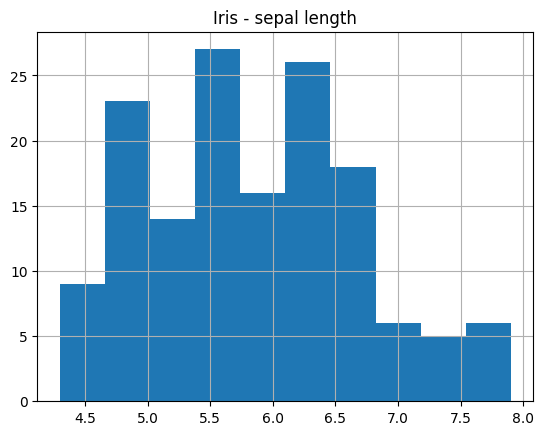

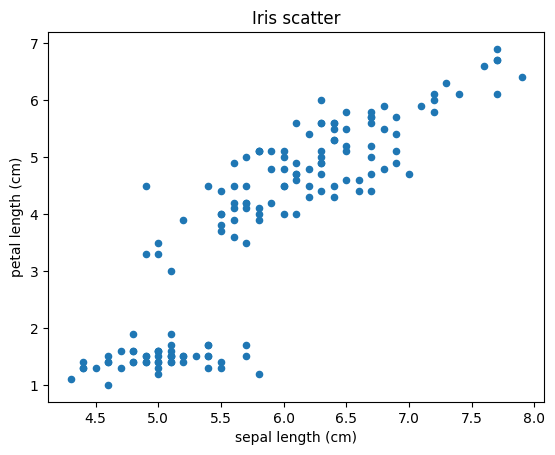

In [43]:
# dataset 1 iris
data = load_iris(as_frame=True)
df = data.frame

print(df.head())
print("\nshape:", df.shape)
print("\nnull values:")
print(df.isnull().sum())
print("\nduplicate rows:", df.duplicated().sum())
print("\nstatistics:")
print(df.describe())

df["sepal length (cm)"].hist()
plt.title("Iris - sepal length")
plt.show()

df.plot.scatter(x="sepal length (cm)", y="petal length (cm)")
plt.title("Iris scatter")
plt.show()

### Dataset 2 - Wine

   alcohol  malic_acid   ash  ...  od280/od315_of_diluted_wines  proline  target
0    14.23        1.71  2.43  ...                          3.92   1065.0       0
1    13.20        1.78  2.14  ...                          3.40   1050.0       0
2    13.16        2.36  2.67  ...                          3.17   1185.0       0
3    14.37        1.95  2.50  ...                          3.45   1480.0       0
4    13.24        2.59  2.87  ...                          2.93    735.0       0

[5 rows x 14 columns]

shape: (178, 14)

null values:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target           

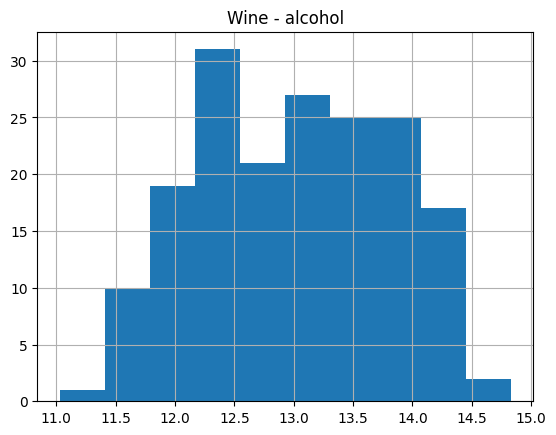

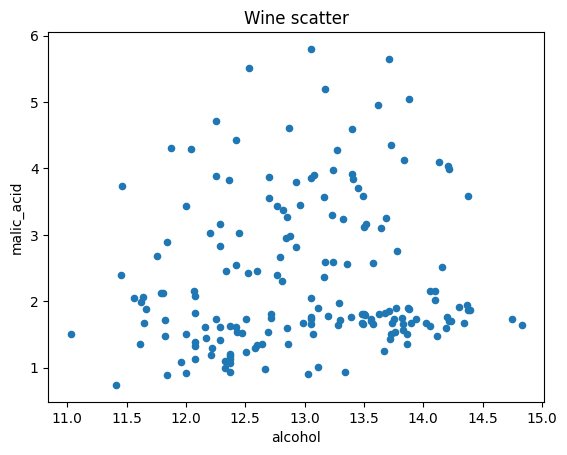

In [44]:
# dataset 2 wine
data = load_wine(as_frame=True)
df = data.frame

print(df.head())
print("\nshape:", df.shape)
print("\nnull values:")
print(df.isnull().sum())
print("\nduplicate rows:", df.duplicated().sum())
print("\nstatistics:")
print(df.describe())

df["alcohol"].hist()
plt.title("Wine - alcohol")
plt.show()

df.plot.scatter(x="alcohol", y="malic_acid")
plt.title("Wine scatter")
plt.show()

### Dataset 3 - Breast Cancer

   mean radius  mean texture  ...  worst fractal dimension  target
0        17.99         10.38  ...                  0.11890       0
1        20.57         17.77  ...                  0.08902       0
2        19.69         21.25  ...                  0.08758       0
3        11.42         20.38  ...                  0.17300       0
4        20.29         14.34  ...                  0.07678       0

[5 rows x 31 columns]

shape: (569, 31)

null values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error       


duplicate rows: 0

statistics:
       mean radius  mean texture  ...  worst fractal dimension      target
count   569.000000    569.000000  ...               569.000000  569.000000
mean     14.127292     19.289649  ...                 0.083946    0.627417
std       3.524049      4.301036  ...                 0.018061    0.483918
min       6.981000      9.710000  ...                 0.055040    0.000000
25%      11.700000     16.170000  ...                 0.071460    0.000000
50%      13.370000     18.840000  ...                 0.080040    1.000000
75%      15.780000     21.800000  ...                 0.092080    1.000000
max      28.110000     39.280000  ...                 0.207500    1.000000

[8 rows x 31 columns]


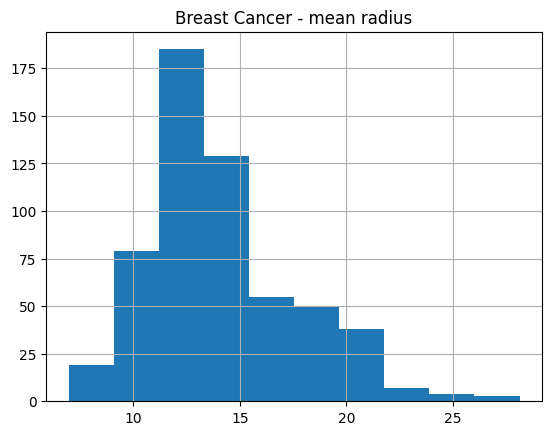

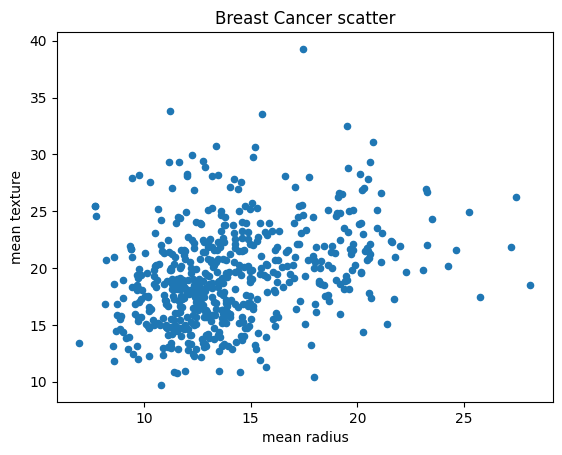

In [45]:
# dataset 3 breast cancer
data = load_breast_cancer(as_frame=True)
df = data.frame

print(df.head())
print("\nshape:", df.shape)
print("\nnull values:")
print(df.isnull().sum())
print("\nduplicate rows:", df.duplicated().sum())
print("\nstatistics:")
print(df.describe())

df["mean radius"].hist()
plt.title("Breast Cancer - mean radius")
plt.show()

df.plot.scatter(x="mean radius", y="mean texture")
plt.title("Breast Cancer scatter")
plt.show()

### Dataset 4 - Diabetes

        age       sex       bmi        bp  ...        s4        s5        s6  target
0  0.038076  0.050680  0.061696  0.021872  ... -0.002592  0.019907 -0.017646   151.0
1 -0.001882 -0.044642 -0.051474 -0.026328  ... -0.039493 -0.068332 -0.092204    75.0
2  0.085299  0.050680  0.044451 -0.005670  ... -0.002592  0.002861 -0.025930   141.0
3 -0.089063 -0.044642 -0.011595 -0.036656  ...  0.034309  0.022688 -0.009362   206.0
4  0.005383 -0.044642 -0.036385  0.021872  ... -0.002592 -0.031988 -0.046641   135.0

[5 rows x 11 columns]

shape: (442, 11)

null values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

duplicate rows: 0

statistics:
                age           sex  ...            s6      target
count  4.420000e+02  4.420000e+02  ...  4.420000e+02  442.000000
mean  -2.511817e-19  1.230790e-17  ...  1.130318e-17  152.133484
std    4.761905e-02  4.761905e-02  ...  4.761905e-02   77.09300

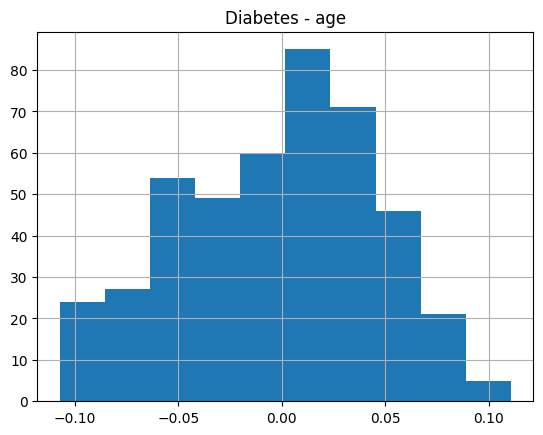

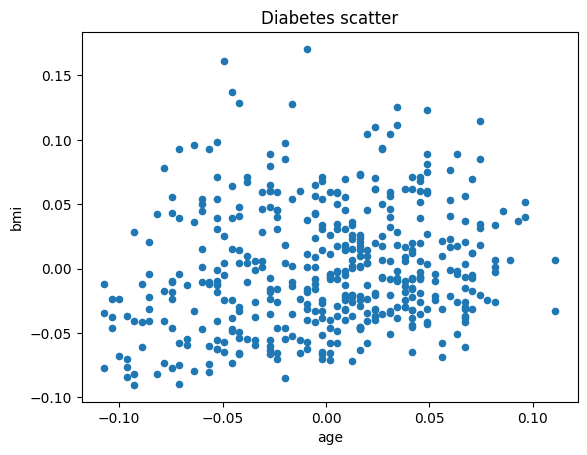

In [46]:
# dataset 4 diabetes
data = load_diabetes(as_frame=True)
df = data.frame

print(df.head())
print("\nshape:", df.shape)
print("\nnull values:")
print(df.isnull().sum())
print("\nduplicate rows:", df.duplicated().sum())
print("\nstatistics:")
print(df.describe())

df["age"].hist()
plt.title("Diabetes - age")
plt.show()

df.plot.scatter(x="age", y="bmi")
plt.title("Diabetes scatter")
plt.show()

### Dataset 5 - Digits

   pixel_0_0  pixel_0_1  pixel_0_2  ...  pixel_7_6  pixel_7_7  target
0        0.0        0.0        5.0  ...        0.0        0.0       0
1        0.0        0.0        0.0  ...        0.0        0.0       1
2        0.0        0.0        0.0  ...        9.0        0.0       2
3        0.0        0.0        7.0  ...        0.0        0.0       3
4        0.0        0.0        0.0  ...        0.0        0.0       4

[5 rows x 65 columns]

shape: (1797, 65)

null values:
pixel_0_0    0
pixel_0_1    0
pixel_0_2    0
pixel_0_3    0
pixel_0_4    0
            ..
pixel_7_4    0
pixel_7_5    0
pixel_7_6    0
pixel_7_7    0
target       0
Length: 65, dtype: int64



duplicate rows: 0

statistics:
       pixel_0_0    pixel_0_1  ...    pixel_7_7       target
count     1797.0  1797.000000  ...  1797.000000  1797.000000
mean         0.0     0.303840  ...     0.364496     4.490818
std          0.0     0.907192  ...     1.860122     2.865304
min          0.0     0.000000  ...     0.000000     0.000000
25%          0.0     0.000000  ...     0.000000     2.000000
50%          0.0     0.000000  ...     0.000000     4.000000
75%          0.0     0.000000  ...     0.000000     7.000000
max          0.0     8.000000  ...    16.000000     9.000000

[8 rows x 65 columns]


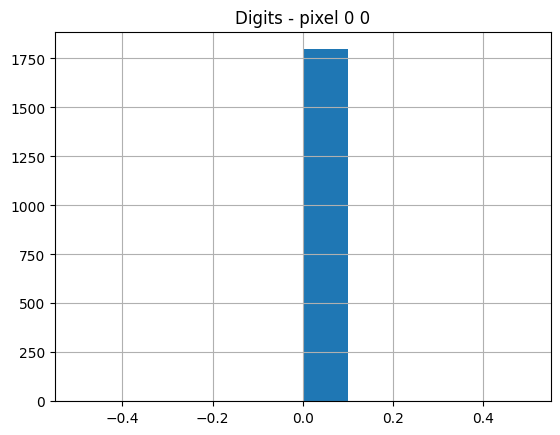

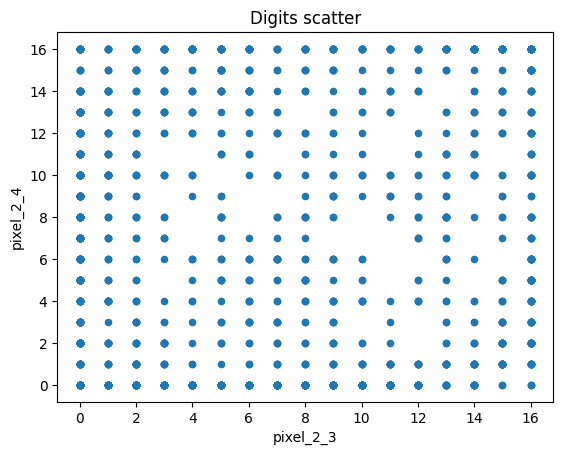

In [47]:
# dataset 5 digits
data = load_digits(as_frame=True)
df = data.frame

print(df.head())
print("\nshape:", df.shape)
print("\nnull values:")
print(df.isnull().sum())
print("\nduplicate rows:", df.duplicated().sum())
print("\nstatistics:")
print(df.describe())

df["pixel_0_0"].hist()
plt.title("Digits - pixel 0 0")
plt.show()

df.plot.scatter(x="pixel_2_3", y="pixel_2_4")
plt.title("Digits scatter")
plt.show()

### Dataset 6 - Longley

    TOTEMP  GNPDEFL       GNP   UNEMP   ARMED       POP    YEAR
0  60323.0     83.0  234289.0  2356.0  1590.0  107608.0  1947.0
1  61122.0     88.5  259426.0  2325.0  1456.0  108632.0  1948.0
2  60171.0     88.2  258054.0  3682.0  1616.0  109773.0  1949.0
3  61187.0     89.5  284599.0  3351.0  1650.0  110929.0  1950.0
4  63221.0     96.2  328975.0  2099.0  3099.0  112075.0  1951.0

shape: (16, 7)

null values:
TOTEMP     0
GNPDEFL    0
GNP        0
UNEMP      0
ARMED      0
POP        0
YEAR       0
dtype: int64

duplicate rows: 0

statistics:
             TOTEMP     GNPDEFL  ...            POP         YEAR
count     16.000000   16.000000  ...      16.000000    16.000000
mean   65317.000000  101.681250  ...  117424.000000  1954.500000
std     3511.968356   10.791553  ...    6956.101561     4.760952
min    60171.000000   83.000000  ...  107608.000000  1947.000000
25%    62712.500000   94.525000  ...  111788.500000  1950.750000
50%    65504.000000  100.600000  ...  116803.500000  1954.50

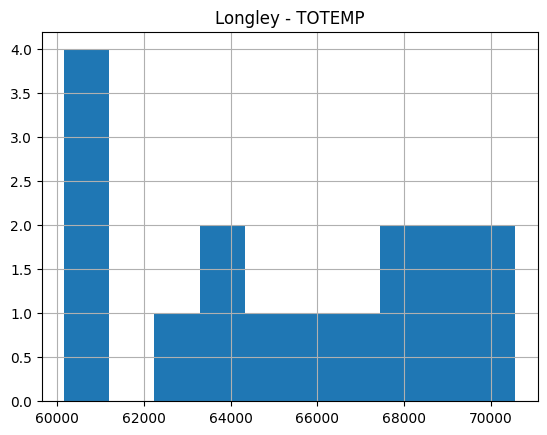

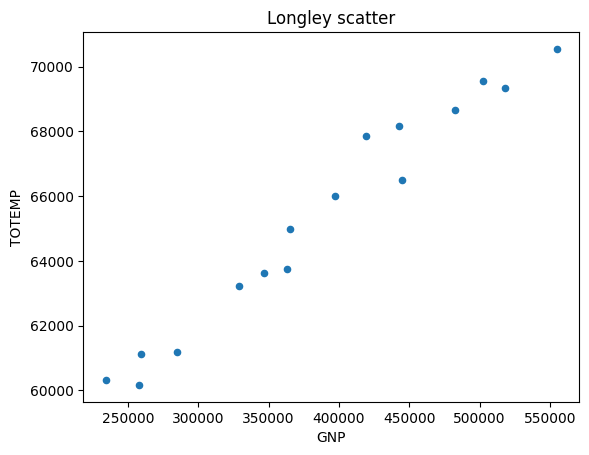

In [48]:
# dataset 6 longley
df = sm.datasets.longley.load_pandas().data

print(df.head())
print("\nshape:", df.shape)
print("\nnull values:")
print(df.isnull().sum())
print("\nduplicate rows:", df.duplicated().sum())
print("\nstatistics:")
print(df.describe())

df["TOTEMP"].hist()
plt.title("Longley - TOTEMP")
plt.show()

df.plot.scatter(x="GNP", y="TOTEMP")
plt.title("Longley scatter")
plt.show()

### Dataset 7 - Stackloss

   STACKLOSS  AIRFLOW  WATERTEMP  ACIDCONC
0       42.0     80.0       27.0      89.0
1       37.0     80.0       27.0      88.0
2       37.0     75.0       25.0      90.0
3       28.0     62.0       24.0      87.0
4       18.0     62.0       22.0      87.0

shape: (21, 4)

null values:
STACKLOSS    0
AIRFLOW      0
WATERTEMP    0
ACIDCONC     0
dtype: int64

duplicate rows: 0

statistics:
       STACKLOSS    AIRFLOW  WATERTEMP   ACIDCONC
count  21.000000  21.000000  21.000000  21.000000
mean   17.523810  60.428571  21.095238  86.285714
std    10.171623   9.168268   3.160771   5.358571
min     7.000000  50.000000  17.000000  72.000000
25%    11.000000  56.000000  18.000000  82.000000
50%    15.000000  58.000000  20.000000  87.000000
75%    19.000000  62.000000  24.000000  89.000000
max    42.000000  80.000000  27.000000  93.000000


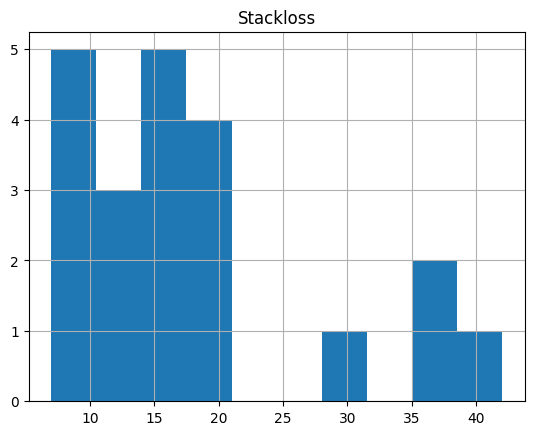

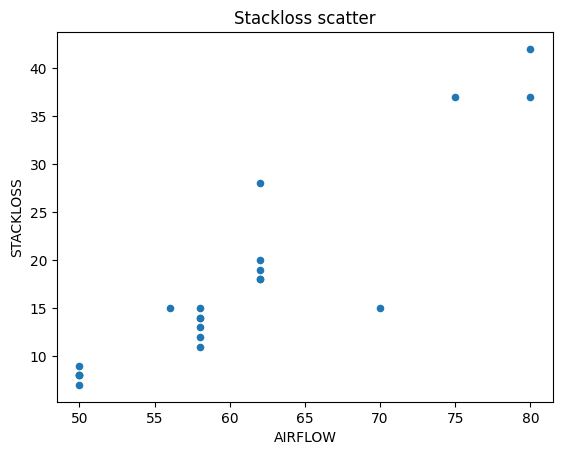

In [49]:
# dataset 7 stackloss
df = sm.datasets.stackloss.load_pandas().data

print(df.head())
print("\nshape:", df.shape)
print("\nnull values:")
print(df.isnull().sum())
print("\nduplicate rows:", df.duplicated().sum())
print("\nstatistics:")
print(df.describe())

df["STACKLOSS"].hist()
plt.title("Stackloss")
plt.show()

df.plot.scatter(x="AIRFLOW", y="STACKLOSS")
plt.title("Stackloss scatter")
plt.show()

### Dataset 8 - Fair

   rate_marriage   age  yrs_married  ...  occupation  occupation_husb   affairs
0            3.0  32.0          9.0  ...         2.0              5.0  0.111111
1            3.0  27.0         13.0  ...         3.0              4.0  3.230769
2            4.0  22.0          2.5  ...         3.0              5.0  1.400000
3            4.0  37.0         16.5  ...         5.0              5.0  0.727273
4            5.0  27.0          9.0  ...         3.0              4.0  4.666666

[5 rows x 9 columns]

shape: (6366, 9)

null values:
rate_marriage      0
age                0
yrs_married        0
children           0
religious          0
educ               0
occupation         0
occupation_husb    0
affairs            0
dtype: int64

duplicate rows: 1039

statistics:
       rate_marriage          age  ...  occupation_husb      affairs
count    6366.000000  6366.000000  ...      6366.000000  6366.000000
mean        4.109645    29.082862  ...         3.850141     0.705374
std         0.961430  

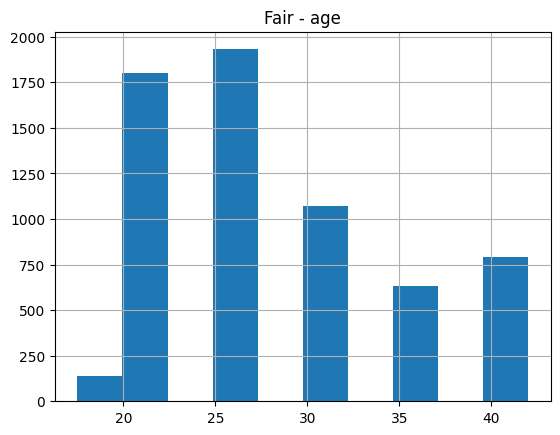

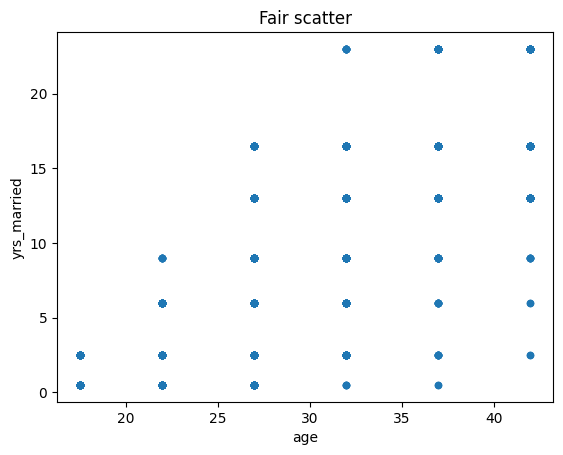

In [50]:
# dataset 8 fair
df = sm.datasets.fair.load_pandas().data

print(df.head())
print("\nshape:", df.shape)
print("\nnull values:")
print(df.isnull().sum())
print("\nduplicate rows:", df.duplicated().sum())
print("\nstatistics:")
print(df.describe())

df["age"].hist()
plt.title("Fair - age")
plt.show()

df.plot.scatter(x="age", y="yrs_married")
plt.title("Fair scatter")
plt.show()

### Dataset 9 - Heart

   survival  censors   age
0      15.0      1.0  54.3
1       3.0      1.0  40.4
2     624.0      1.0  51.0
3      46.0      1.0  42.5
4     127.0      1.0  48.0

shape: (69, 3)

null values:
survival    0
censors     0
age         0
dtype: int64

duplicate rows: 0

statistics:
          survival    censors        age
count    69.000000  69.000000  69.000000
mean    376.797101   0.652174  46.134783
std     458.362000   0.479770   8.874846
min       1.000000   0.000000  19.700000
25%      47.000000   0.000000  42.500000
50%     147.000000   1.000000  48.000000
75%     592.000000   1.000000  52.200000
max    1775.000000   1.000000  64.500000


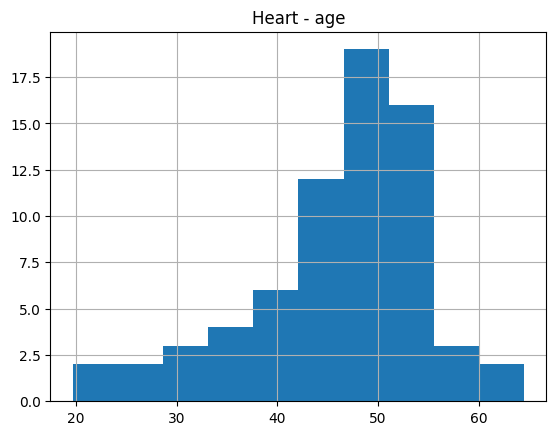

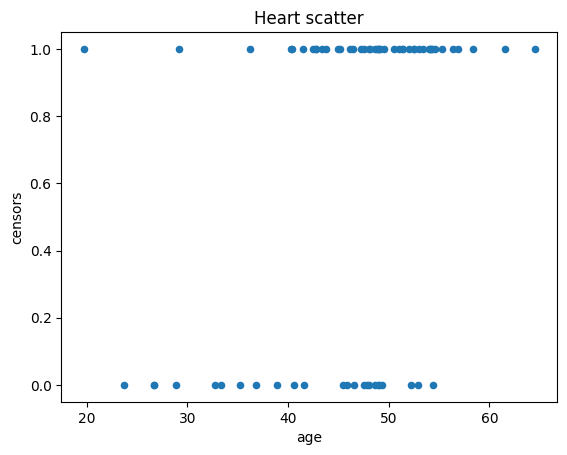

In [51]:
# dataset 9 heart
df = sm.datasets.heart.load_pandas().data

print(df.head())
print("\nshape:", df.shape)
print("\nnull values:")
print(df.isnull().sum())
print("\nduplicate rows:", df.duplicated().sum())
print("\nstatistics:")
print(df.describe())

df["age"].hist()
plt.title("Heart - age")
plt.show()

df.plot.scatter(x="age", y="censors")
plt.title("Heart scatter")
plt.show()

### Dataset 10 - Macrodata

     year  quarter   realgdp  realcons  ...  unemp      pop  infl  realint
0  1959.0      1.0  2710.349    1707.4  ...    5.8  177.146  0.00     0.00
1  1959.0      2.0  2778.801    1733.7  ...    5.1  177.830  2.34     0.74
2  1959.0      3.0  2775.488    1751.8  ...    5.3  178.657  2.74     1.09
3  1959.0      4.0  2785.204    1753.7  ...    5.6  179.386  0.27     4.06
4  1960.0      1.0  2847.699    1770.5  ...    5.2  180.007  2.31     1.19

[5 rows x 14 columns]

shape: (203, 14)

null values:
year        0
quarter     0
realgdp     0
realcons    0
realinv     0
realgovt    0
realdpi     0
cpi         0
m1          0
tbilrate    0
unemp       0
pop         0
infl        0
realint     0
dtype: int64

duplicate rows: 0

statistics:
              year     quarter  ...        infl     realint
count   203.000000  203.000000  ...  203.000000  203.000000
mean   1983.876847    2.492611  ...    3.961330    1.336502
std      14.686817    1.118563  ...    3.253216    2.668799
min    1959.00

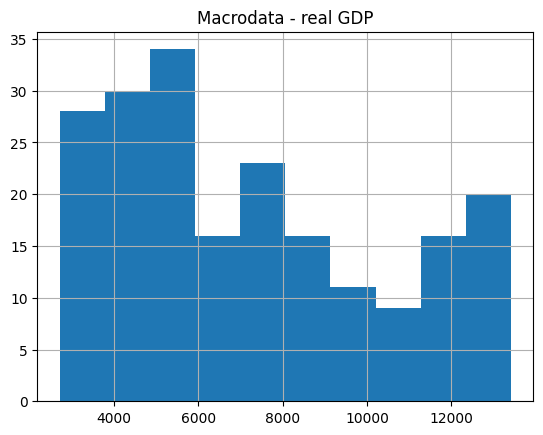

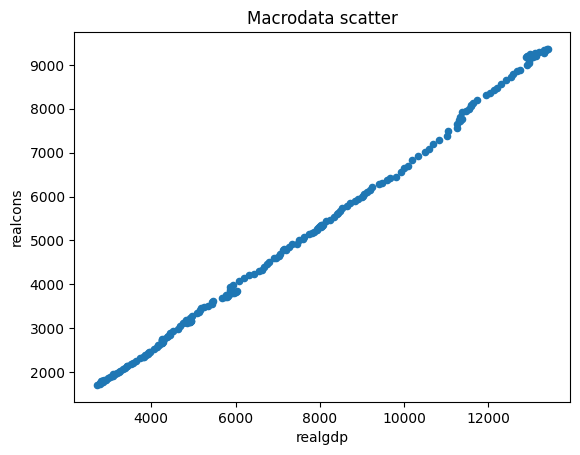

In [52]:
# dataset 10 macrodata
df = sm.datasets.macrodata.load_pandas().data

print(df.head())
print("\nshape:", df.shape)
print("\nnull values:")
print(df.isnull().sum())
print("\nduplicate rows:", df.duplicated().sum())
print("\nstatistics:")
print(df.describe())

df["realgdp"].hist()
plt.title("Macrodata - real GDP")
plt.show()

df.plot.scatter(x="realgdp", y="realcons")
plt.title("Macrodata scatter")
plt.show()